# EX 7B – Baseball Databank / Tableau

Same Tableau-style worksheet, calculated-field and summary-table workflow as the friend's EX 7B, adapted to Baseball data.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(find_data("Batting.csv"))
df["total_runs"] = df["R"]
df["boundary_runs"] = df["HR"] * 4

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (101332, 24)


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,total_runs,boundary_runs
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,30.0,0.0
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN,28.0,0.0
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,28.0,8.0
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,29.0,0.0


In [2]:
print("Duplicate rows:", df.duplicated().sum())

summary = pd.DataFrame({
    "Metric": ["Players", "Seasons", "Player-Seasons", "Total Runs", "Boundary Runs"],
    "Value": [df.playerID.nunique(), df.yearID.nunique(), len(df), int(df.total_runs.sum()), int(df.boundary_runs.sum())]
})
display(summary)

Duplicate rows: 0


,Metric,Value
0,Players,18659
1,Seasons,145
2,Player-Seasons,101332
3,Total Runs,1912795
4,Boundary Runs,1134692


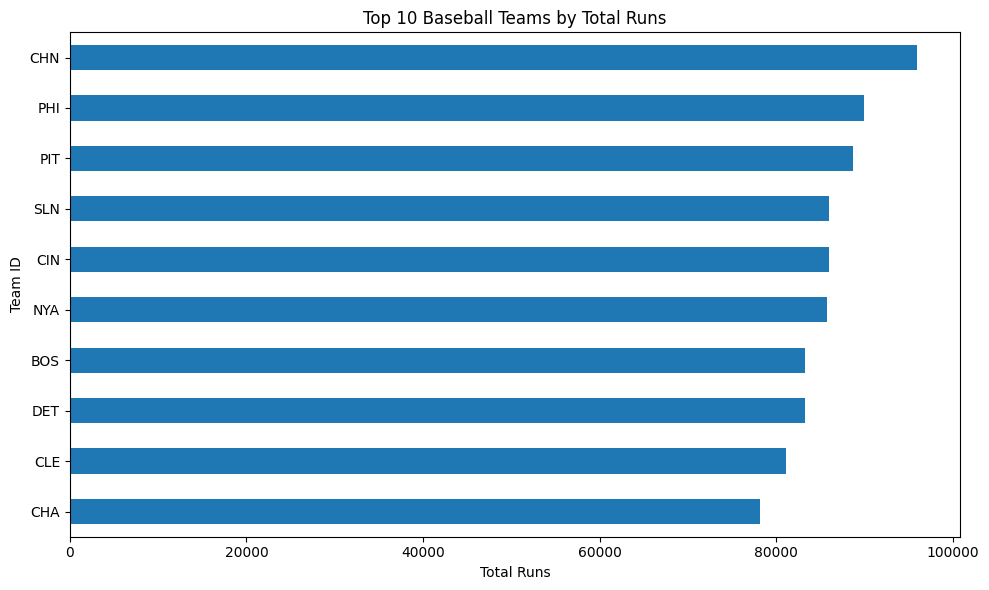

In [3]:
team_runs = df.groupby("teamID")["total_runs"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
team_runs.sort_values().plot(kind="barh")
plt.title("Top 10 Baseball Teams by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Team ID")
plt.tight_layout()
plt.savefig("Experiment_7B_Baseball_Team_Bar.png", dpi=150, bbox_inches="tight")
plt.show()

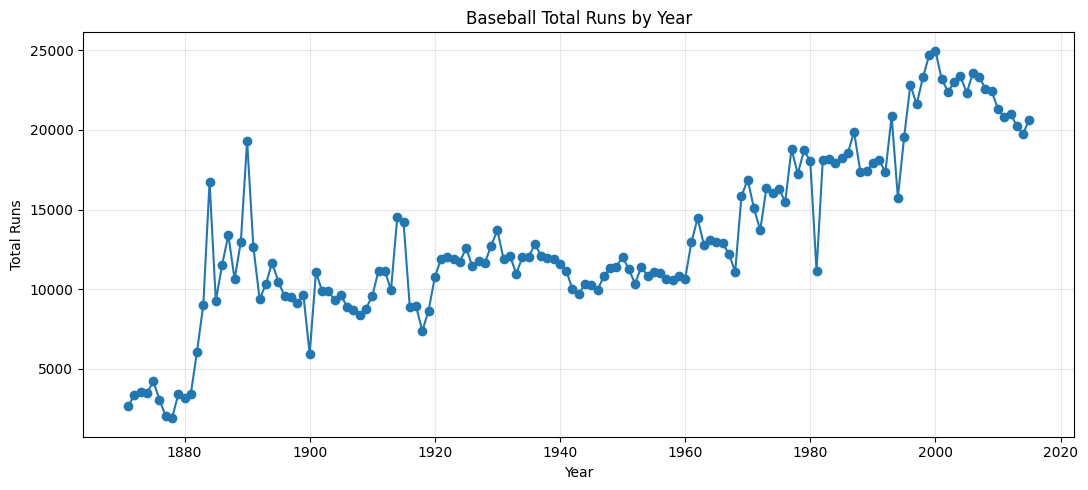

In [4]:
season_runs = df.groupby("yearID")["total_runs"].sum()

plt.figure(figsize=(11,5))
season_runs.plot(kind="line", marker="o")
plt.title("Baseball Total Runs by Year")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Experiment_7B_Baseball_Year_Line.png", dpi=150, bbox_inches="tight")
plt.show()

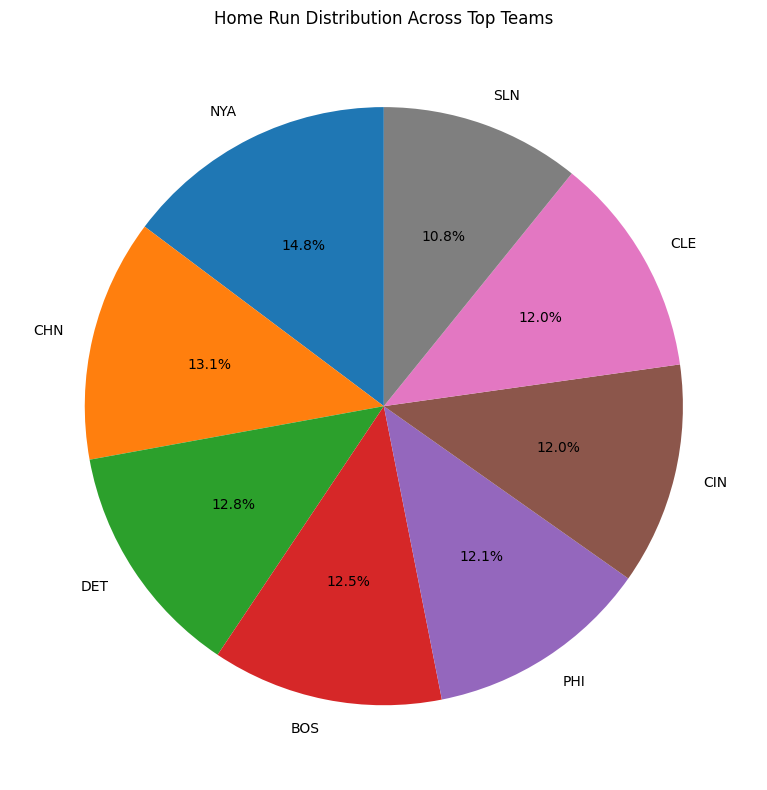

In [5]:
top_hr = df.groupby("teamID")["HR"].sum().nlargest(8)

plt.figure(figsize=(8,8))
plt.pie(top_hr.values, labels=top_hr.index, autopct="%1.1f%%", startangle=90)
plt.title("Home Run Distribution Across Top Teams")
plt.tight_layout()
plt.savefig("Experiment_7B_Baseball_HomeRun_Pie.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
team_summary = df.groupby("teamID").agg(
    Total_Runs=("total_runs","sum"),
    Boundary_Runs=("boundary_runs","sum"),
    Player_Seasons=("playerID","size")
).sort_values("Total_Runs", ascending=False).head(10)

display(team_summary)

,Total_Runs,Boundary_Runs,Player_Seasons
teamID,,,
CHN,96003.0,54120.0,4818
PHI,89959.0,50012.0,4721
PIT,88658.0,43512.0,4667
SLN,86003.0,44628.0,4627
CIN,85970.0,49532.0,4488
NYA,85715.0,60872.0,4220
BOS,83309.0,51532.0,4278
DET,83222.0,52640.0,4172
CLE,81116.0,49332.0,4451


In [7]:
print("Total Runs = SUM([total_runs])")
print("Boundary Runs = SUM([boundary_runs])")
print("Players = COUNTD([playerID])")
print("Home Runs = SUM([HR])")

Total Runs = SUM([total_runs])
Boundary Runs = SUM([boundary_runs])
Players = COUNTD([playerID])
Home Runs = SUM([HR])
